In [631]:
path_to_data = '/Users/razakamiandra/WORKSPACE/Field_Response/OUTPUT_FR/JUNE13/store_0.1mmSpacing_0.05usTimestep'
# path_to_data = '/Users/razakamiandra/WORKSPACE/Field_Response/OUTPUT_FR/JUNE29/store_0.1mmspacing_0.05ustimestep_0mmPPwidth'
# path_to_data = '/Users/razakamiandra/WORKSPACE/Field_Response/OUTPUT_FR/JUNE13/store_0.05mmSpacing_0.05usTimestep'

import numpy as np
import os
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use('CMS')

fr = np.load('/'.join([path_to_data, 'fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy']))
fr = fr.reshape(25,25,6399)*1000
shifted_paths = np.load('/'.join([path_to_data, 'tmp/shifted_paths.npy'])).reshape(25,25, 6400, 3)

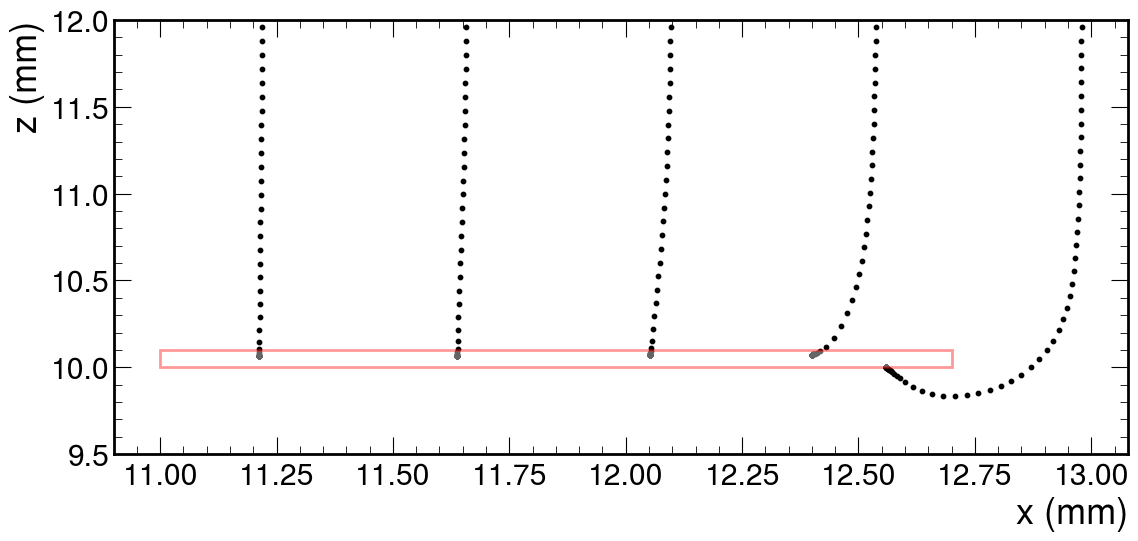

In [632]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12,6))

for i in range(len(shifted_paths[:5, 4, 0, 0])):
    ax.scatter(shifted_paths[i, 4, :, 0], shifted_paths[i, 4, :, 2], s=10, color='black')

# Pixel pad x boundaries (left edge, right edge pairs)
pixel_pads = [
    (11, 12.7),
    # (11, 12.9),
    # (12.9+0.6, 12.9+4.4),
    # (12.9+0.6+4.4, 12.9+8.8)
]

z_bottom = 10.0
z_top = 10.1

for (x_left, x_right) in pixel_pads:
    rect = patches.Rectangle(
        (x_left, z_bottom),
        x_right - x_left,
        z_top - z_bottom,
        linewidth=2,
        edgecolor='red',
        facecolor='white',
        alpha=0.4
    )
    ax.add_patch(rect)

# ax.set_xticks(np.arange(11, 23, 1))
ax.set_xlabel('x (mm)')
ax.set_ylabel('z (mm)')
# ax.axvline(12.6, linestyle='--')
# ax.axvline(12.7, linestyle='--')
# ax.axvline(12.8, linestyle='--')
# ax.axvline(12.9, linestyle='--')
# ax.set_ylim(9, 20)
# plt.ylim(-1, 10)
# plt.ylim(9.8, 10.2)
plt.ylim(9.5, 12)
# plt.ylim(9.7, 10.2)
# plt.xlim(12.8, 12.95)
# plt.xlim(12.5, 13)
plt.tight_layout()
plt.show()

In [633]:
velocity = np.load('/'.join([path_to_data, 'velocity/drift3d.npz']))['drift3d']
velocity.shape

(3, 44, 44, 300)

Text(0.5, 1.0, 'Drift velocity at the corner of the pixel')

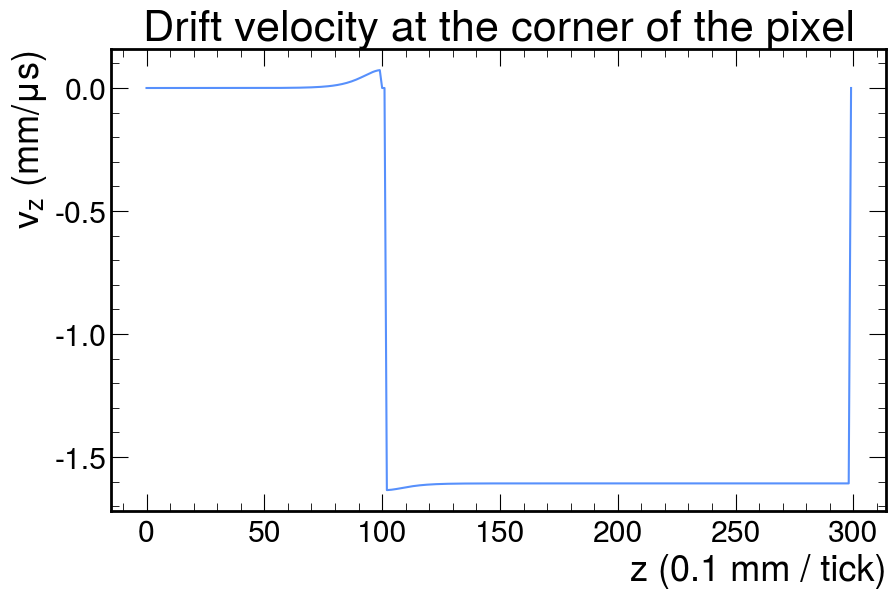

In [634]:
plt.figure(figsize=(10,6))
plt.plot(velocity[2, 38,38, :]*1000)
plt.xlabel('z (0.1 mm / tick)')
plt.ylabel(r'$v_z$ (mm/$\mu s$)')
plt.title('Drift velocity at the corner of the pixel')

In [635]:
drift = np.load('/'.join([path_to_data, 'potential/drift3d.npz']))['drift3d']
drift.shape

(44, 44, 300)

In [636]:
drift_diff = drift[4,4,1:] - drift[4,4,:-1]

(150.0, 250.0)

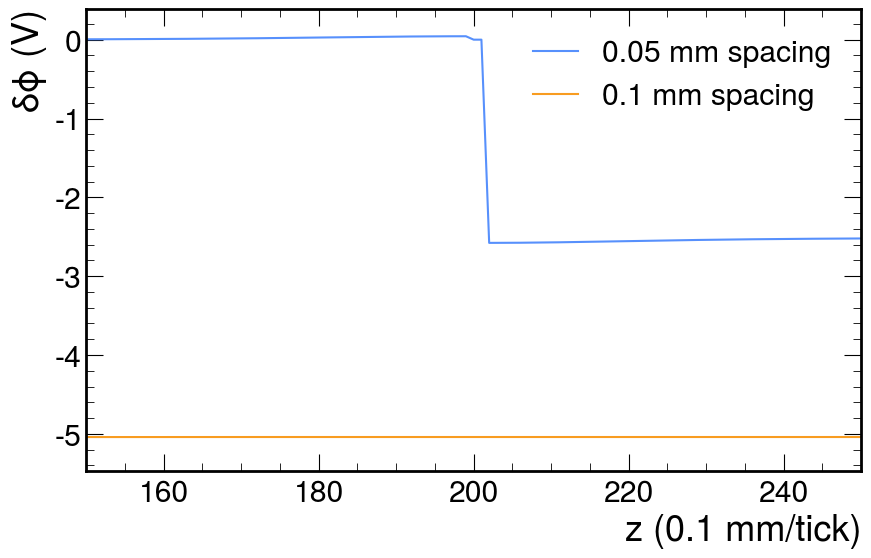

In [637]:
plt.figure(figsize=(10, 6))
plt.plot(drift_diff_0, label='0.05 mm spacing')
plt.plot(drift_diff, label='0.1 mm spacing')
plt.xlabel('z (0.1 mm/tick)')
plt.ylabel(r'$\delta\phi$ (V)')
plt.legend()
plt.xlim(150, 250)
# plt.ylim(-50, 10)

In [638]:
fr = np.load('/'.join([path_to_data, 'fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy']))
fr = fr.reshape(25,25,6399)*1000

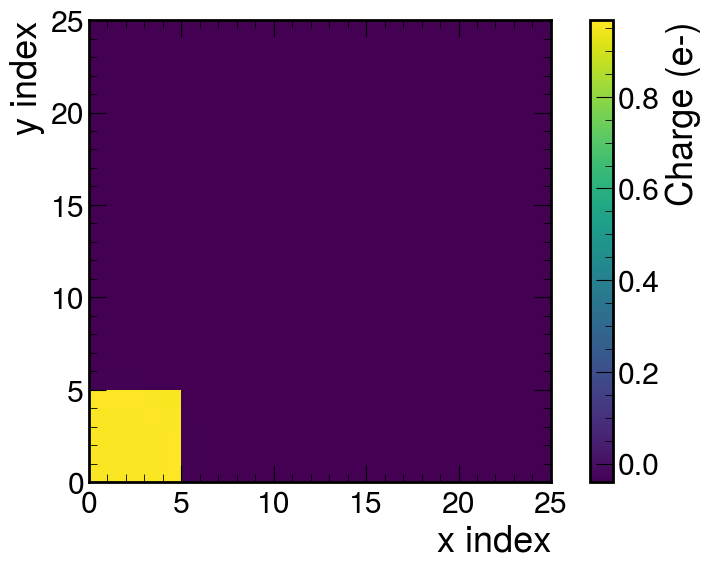

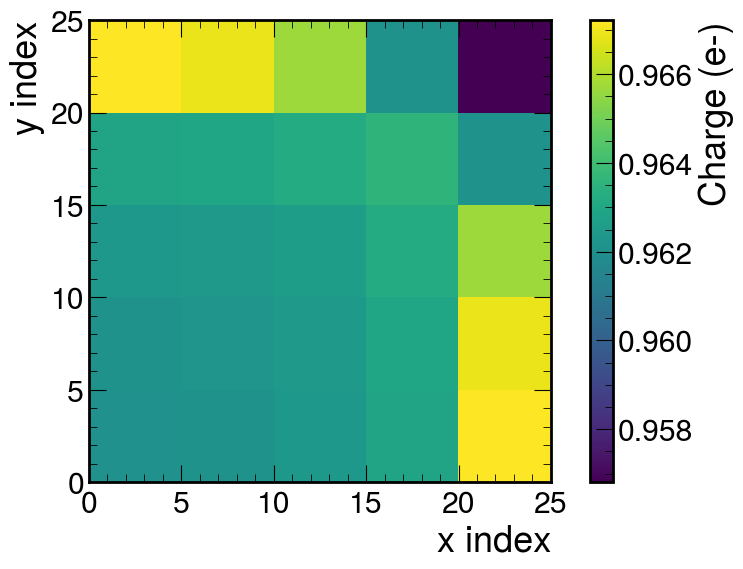

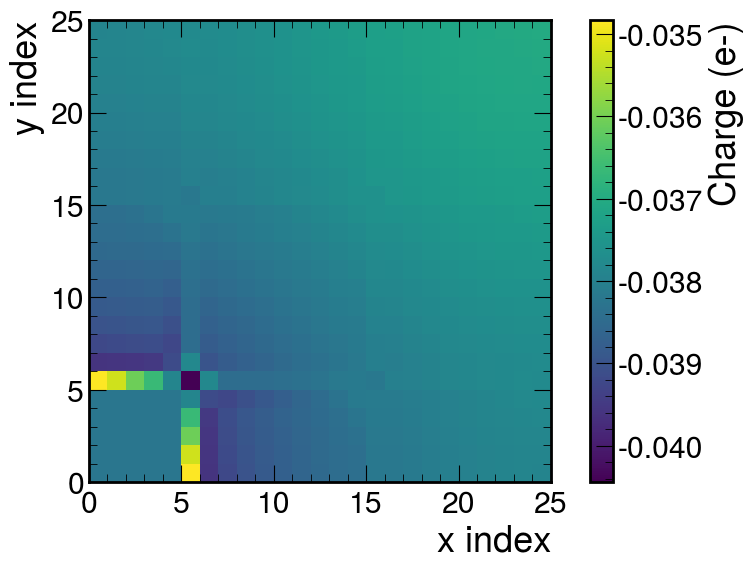

In [639]:
from scipy.integrate import simpson
fr_integral = simpson(fr, dx=0.05, axis=2)
plt.figure(figsize=(10,6))
plt.imshow(fr_integral, cmap='viridis', origin='lower', extent=[0, 25, 0, 25])
plt.xlabel('x index')
plt.ylabel('y index')
plt.colorbar(label='Charge (e-)')

plt.figure(figsize=(10,6))
plt.imshow(fr_integral[:5, :5], cmap='viridis', origin='lower', extent=[0, 25, 0, 25])
plt.xlabel('x index')
plt.ylabel('y index')
plt.colorbar(label='Charge (e-)')

fr_copy_integral = simpson(fr, dx=0.05, axis=2)
fr_copy_integral[:5, :5] = np.min(fr_copy_integral[10:, 10:])
plt.figure(figsize=(10,6))
plt.imshow(fr_copy_integral, cmap='viridis', origin='lower', extent=[0, 25, 0, 25])
plt.xlabel('x index')
plt.ylabel('y index')
plt.colorbar(label='Charge (e-)')

## Integration-method comparison for the induced-current integral

The induced current `fr` is produced as a finite difference `I = dQ/dT` with a **uniform** time step (`induce_pixel` in `pochoir/__main__.py`: `I_tot = (Q[:,1:]-Q[:,:-1]) / dT`). With constant `dT`, the exact time integral telescopes:

`∫ I dt = Σ I·dt = Σ dQ = Q_end − Q_start`

so the left-Riemann / `fr.sum(axis=2)*dx` sum reproduces it exactly and `trapezoid` matches it to ~1e-6. `simpson` fits parabolas across the already-differenced sequence and overshoots each spiky waveform differently — which is what makes the per-path integral **non-uniform across the central-pixel block**. The cells below compare the methods, prove the telescoping identity, and show the spatial structure of the Simpson artifact.

In [ ]:
# Integrate the induced current with several methods and build one charge map per method.
from scipy.integrate import simpson, trapezoid, romb

dx = 0.05  # us per time tick

maps = {
    "left_riemann": fr.sum(axis=2) * dx,         # == Q_end - Q_start, exact for I = dQ/dT
    "trapezoid":    trapezoid(fr, dx=dx, axis=2),
    "simpson":      simpson(fr, dx=dx, axis=2),  # method currently used above
}

# romb needs 2**k + 1 samples along the time axis; truncate to the largest such window.
n = fr.shape[2]
k = int(np.floor(np.log2(n - 1)))
m = 2**k + 1
maps["romb_trunc"] = romb(fr[:, :, :m], dx=dx, axis=2)
print(f"romb uses the first {m} of {n} samples (drops the {n - m}-sample tail, which is ~0)")

In [ ]:
# Statistics over the central-pixel "collecting" block (cells far from zero).
mask = np.abs(maps["simpson"]) > 0.5
print(f"central-pixel block: {mask.sum()} cells\n")
print(f"{'method':14s}{'mean':>12s}{'std':>12s}{'min':>12s}{'max':>12s}")
for name, m_ in maps.items():
    v = m_[mask]
    print(f"{name:14s}{v.mean():12.6f}{v.std():12.2e}{v.min():12.6f}{v.max():12.6f}")
print("\nleft_riemann/trapezoid std ~ 5e-5 (uniform); simpson std ~ 2e-3 (~45x larger).")

In [ ]:
# Telescoping identity on the brightest block cell: I = dQ/dT with constant dT
# => integral exactly equals Q_end - Q_start = fr.sum()*dx (left-Riemann).
y, x = np.unravel_index(np.argmax(maps["simpson"]), maps["simpson"].shape)
w = fr[y, x]
telescope = w.sum() * dx
print(f"cell ({y},{x}):")
print(f"  left-Riemann sum*dx = {telescope:.8f}   (exact telescope Q_end - Q_start)")
print(f"  trapezoid           = {trapezoid(w, dx=dx):.8f}   "
      f"(diff {trapezoid(w, dx=dx) - telescope:+.2e})")
print(f"  simpson             = {simpson(w, dx=dx):.8f}   "
      f"(diff {simpson(w, dx=dx) - telescope:+.2e}, "
      f"{(simpson(w, dx=dx) - telescope) / telescope * 100:+.3f}%)")

In [ ]:
# Downsampling test: a faithful integral should stay ~stable as we coarsen the sampling.
# Simpson oscillates on the sharp current peak; trapezoid stays put.
print(f"{'step':>5s}{'nsamp':>8s}{'simpson':>14s}{'trapezoid':>14s}")
for step in (1, 2, 4, 8, 16):
    ws = w[::step]
    print(f"{step:5d}{ws.size:8d}{simpson(ws, dx=dx*step):14.6f}{trapezoid(ws, dx=dx*step):14.6f}")

In [ ]:
# Spatial structure of the method artifact: simpson, trapezoid, and their difference.
diff = maps["simpson"] - maps["trapezoid"]
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
for a, key in zip(ax[:2], ("simpson", "trapezoid")):
    im = a.imshow(maps[key], cmap='viridis', origin='lower')
    a.set_title(key)
    a.set_xlabel('x index'); a.set_ylabel('y index')
    fig.colorbar(im, ax=a, label='Charge (e-)')
vlim = np.abs(diff).max()
im = ax[2].imshow(diff, cmap='RdBu_r', origin='lower', vmin=-vlim, vmax=vlim)
ax[2].set_title('simpson - trapezoid (method artifact)')
ax[2].set_xlabel('x index'); ax[2].set_ylabel('y index')
fig.colorbar(im, ax=ax[2], label='Charge diff (e-)')
plt.tight_layout()
plt.show()

### Conclusion

- The ~3.9 % offset of the block integral from 1.0 is **physical** (the drift start point is not at zero weighting potential / charge is not fully collected) and is *uniform* across the central-pixel block.
- The *non-uniformity* across the block is a **Simpson artifact**: the exact integral (`fr.sum(axis=2)*dx` = trapezoid = `Q_end − Q_start`) is uniform to ~5e-5, while Simpson injects a spatially-varying 0.1–0.6 % wobble by fitting parabolas across the already-differenced current.

**Recommendation:** integrate this finite-difference induced current with `trapezoid` (equivalently `fr.sum(axis=2)*dx`), not `simpson`. The residual offset from 1.0 is a separate start-point (weighting-potential) investigation.

-18


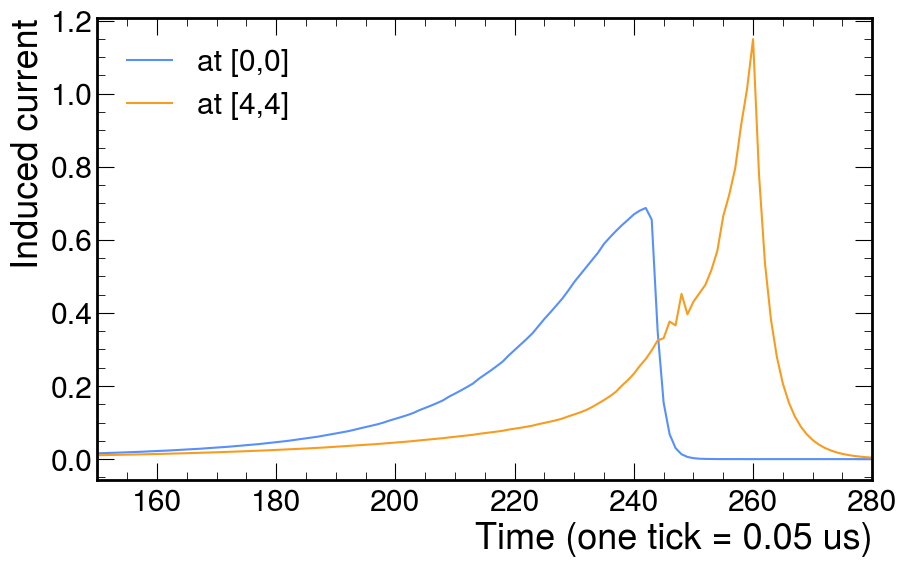

In [640]:
x_range = np.arange(0, fr.shape[2])
shift = (np.argmax(fr[0,0]) - np.argmax(fr[4,4]))
print(shift)
plt.figure(figsize=(10,6))
plt.plot(x_range, fr[0,0], label='at [0,0]')
plt.plot(x_range, fr[4,4], label='at [4,4]')
plt.xlabel('Time (one tick = 0.05 us)')
plt.ylabel('Induced current')
plt.xlim(150, 280)
plt.legend()

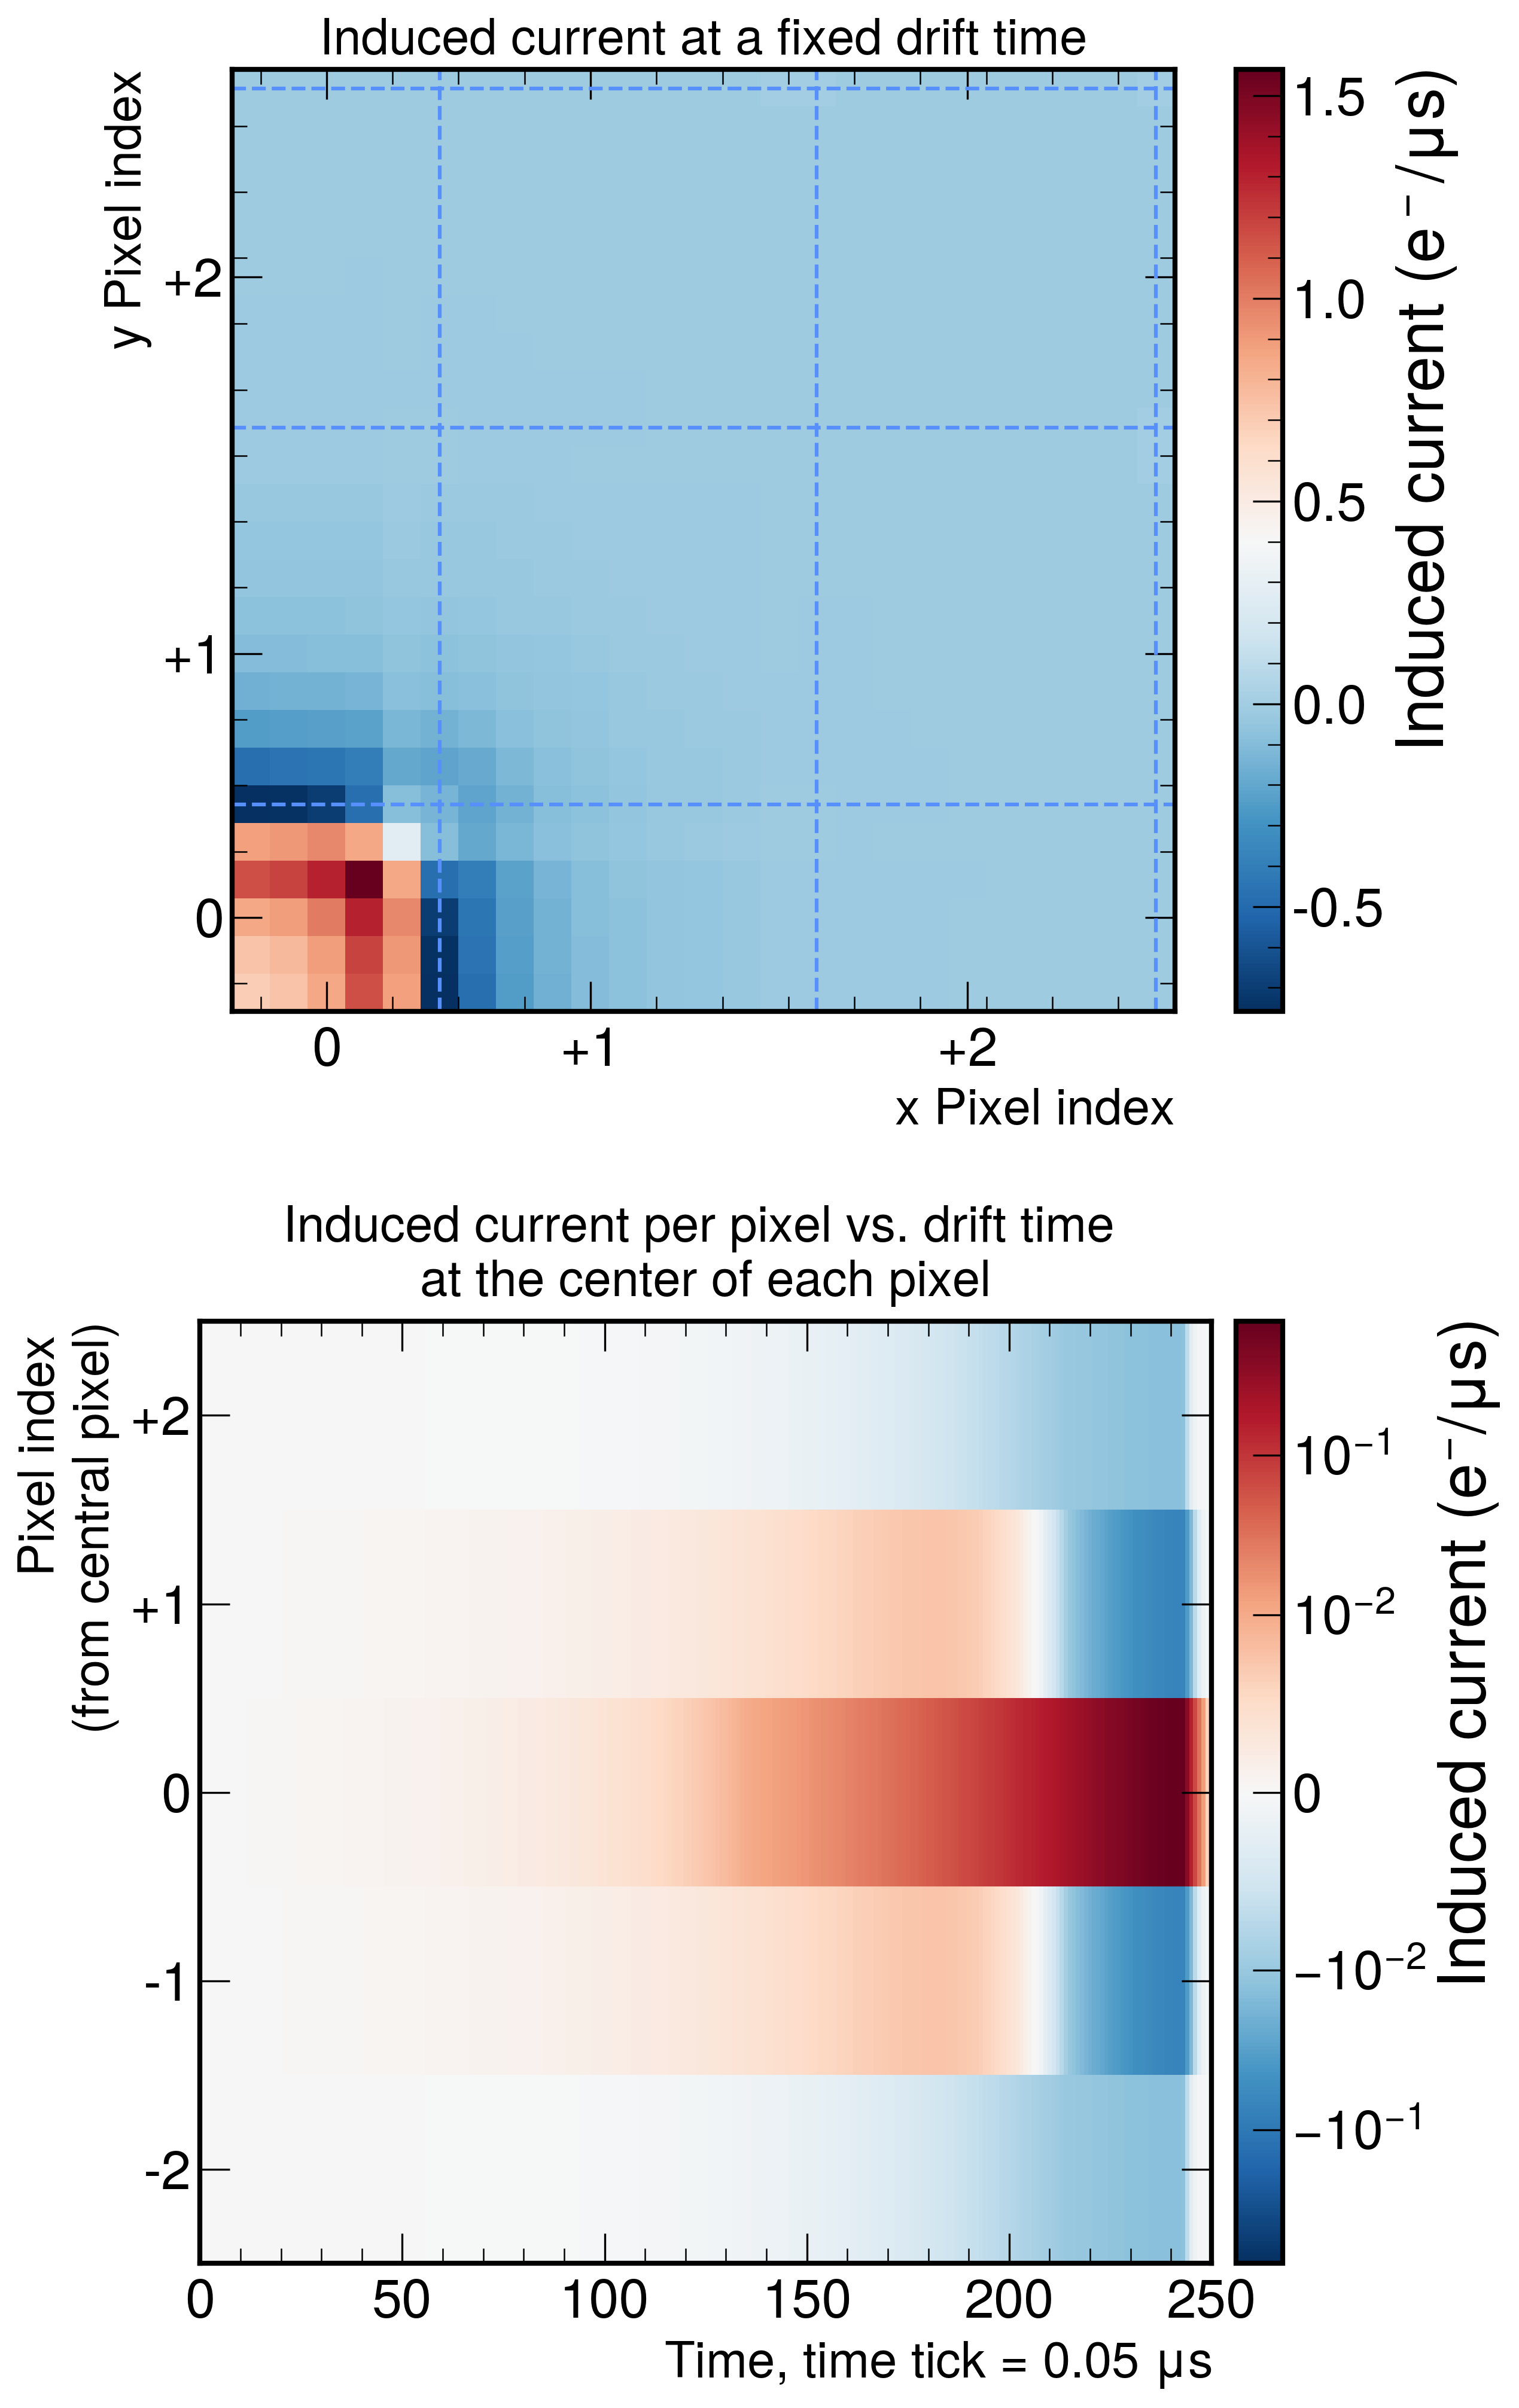

In [641]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

# Assuming 'fr' is your numpy array of shape (25, 25, 2000)
# data = np.load("your_data.npy")
pos_max_centralpix = np.argmax(fr[0,0,:])
# 1. Manually construct the 5-pixel space-time slice using symmetry
space_time_slice = np.zeros((5, 2000))
space_time_slice[0, :] = fr[20, 0, :2000] # Pixel -2
space_time_slice[1, :] = fr[10, 0, :2000] # Pixel -1
space_time_slice[2, :] = fr[0,  0, :2000] # Pixel  0
space_time_slice[3, :] = fr[10, 0, :2000] # Pixel +1
space_time_slice[4, :] = fr[20, 0, :2000] # Pixel +2

# 2. Set up the coordinate grids
time_ticks = np.arange(2000)
pixel_offsets = np.array([-2, -1, 0, 1, 2])
T, P = np.meshgrid(time_ticks, pixel_offsets)

# =====================================================================
# PLOT RECREATION WITH SYMMETRIC LOG SCALE
# =====================================================================
fig, ax = plt.subplots(2,1, figsize=(9, 7*2), dpi=300)

# Force the colorbar limits to be perfectly symmetric around 0.0
vmax = np.max(np.abs(space_time_slice))

# linthresh defines the linear region close to 0.
linthresh = 0.01

norm = mcolors.SymLogNorm(
    linthresh=linthresh,
    linscale=1.0,
    vmin=-vmax,
    vmax=vmax,
    base=10
)

# Plot the matrix. shading='nearest' -> one discrete cell per pixel row,
# no interpolation between pixels (each band is a single pixel center).
c = ax[1].pcolormesh(T, P, space_time_slice, cmap='RdBu_r', norm=norm, shading='nearest')

# Colorbar adjustments
cbar = fig.colorbar(c, ax=ax[1], pad=0.02)
cbar.set_label(r'Induced current ($\mathrm{e^{-}/\mu s}$)')
cbar.locator = mticker.SymmetricalLogLocator(base=10, linthresh=linthresh)
cbar.formatter = mticker.LogFormatterMathtext(base=10)
cbar.update_normal(c)

# Zoom into your active time window
# ax[1].set_xlim(1300, 1730)
ax[1].set_xlim(0, 250)
ax[1].set_ylim(-2.5, 2.5)

# Formatting axes: discrete pixel index, NOT a continuous lateral coordinate
ax[1].set_yticks(pixel_offsets)
ax[1].set_yticklabels(['-2', '-1', '0', '+1', '+2'])
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[1].set_xlabel(r'Time, time tick = $0.05\ \mu\mathrm{s}$', fontsize=20)
ax[1].set_ylabel('Pixel index \n (from central pixel)', fontsize=20)
ax[1].set_title('Induced current per pixel vs. drift time \nat the center of each pixel', fontsize=20, pad=10)

def pixel_to_region(val, pos):
    if val <= 4:
        return '0'
    elif 5 <= val <= 14:
        return '+1'
    else:
        return '+2'

formatter = FuncFormatter(pixel_to_region)

im = ax[0].imshow(fr[:,:, pos_max_centralpix], cmap='RdBu_r', origin='lower')
fig.colorbar(im, ax=ax[0], label=r'Induced current ($e^-/\mu s$)')

ax[0].axvline(5, linestyle='--')
ax[0].axvline(15, linestyle='--')
ax[0].axvline(24, linestyle='--')
ax[0].axhline(5, linestyle='--')
ax[0].axhline(15, linestyle='--')
ax[0].axhline(24, linestyle='--')

ax[0].xaxis.set_major_formatter(formatter)
ax[0].yaxis.set_major_formatter(formatter)

ax[0].set_xticks([2, 9, 19])
ax[0].set_yticks([2, 9, 19])
ax[0].set_xlabel('x Pixel index', fontsize=20)
ax[0].set_ylabel('y Pixel index', fontsize=20)
ax[0].set_title('Induced current at a fixed drift time', fontsize=20)

plt.tight_layout()
# plt.savefig('lateralChargeCollection.png')
# plt.savefig('symmetric_space_time_contour_log.png')
plt.show()

In [642]:
data = shifted_paths[4,4,202:255, :]
data.shape

(53, 3)

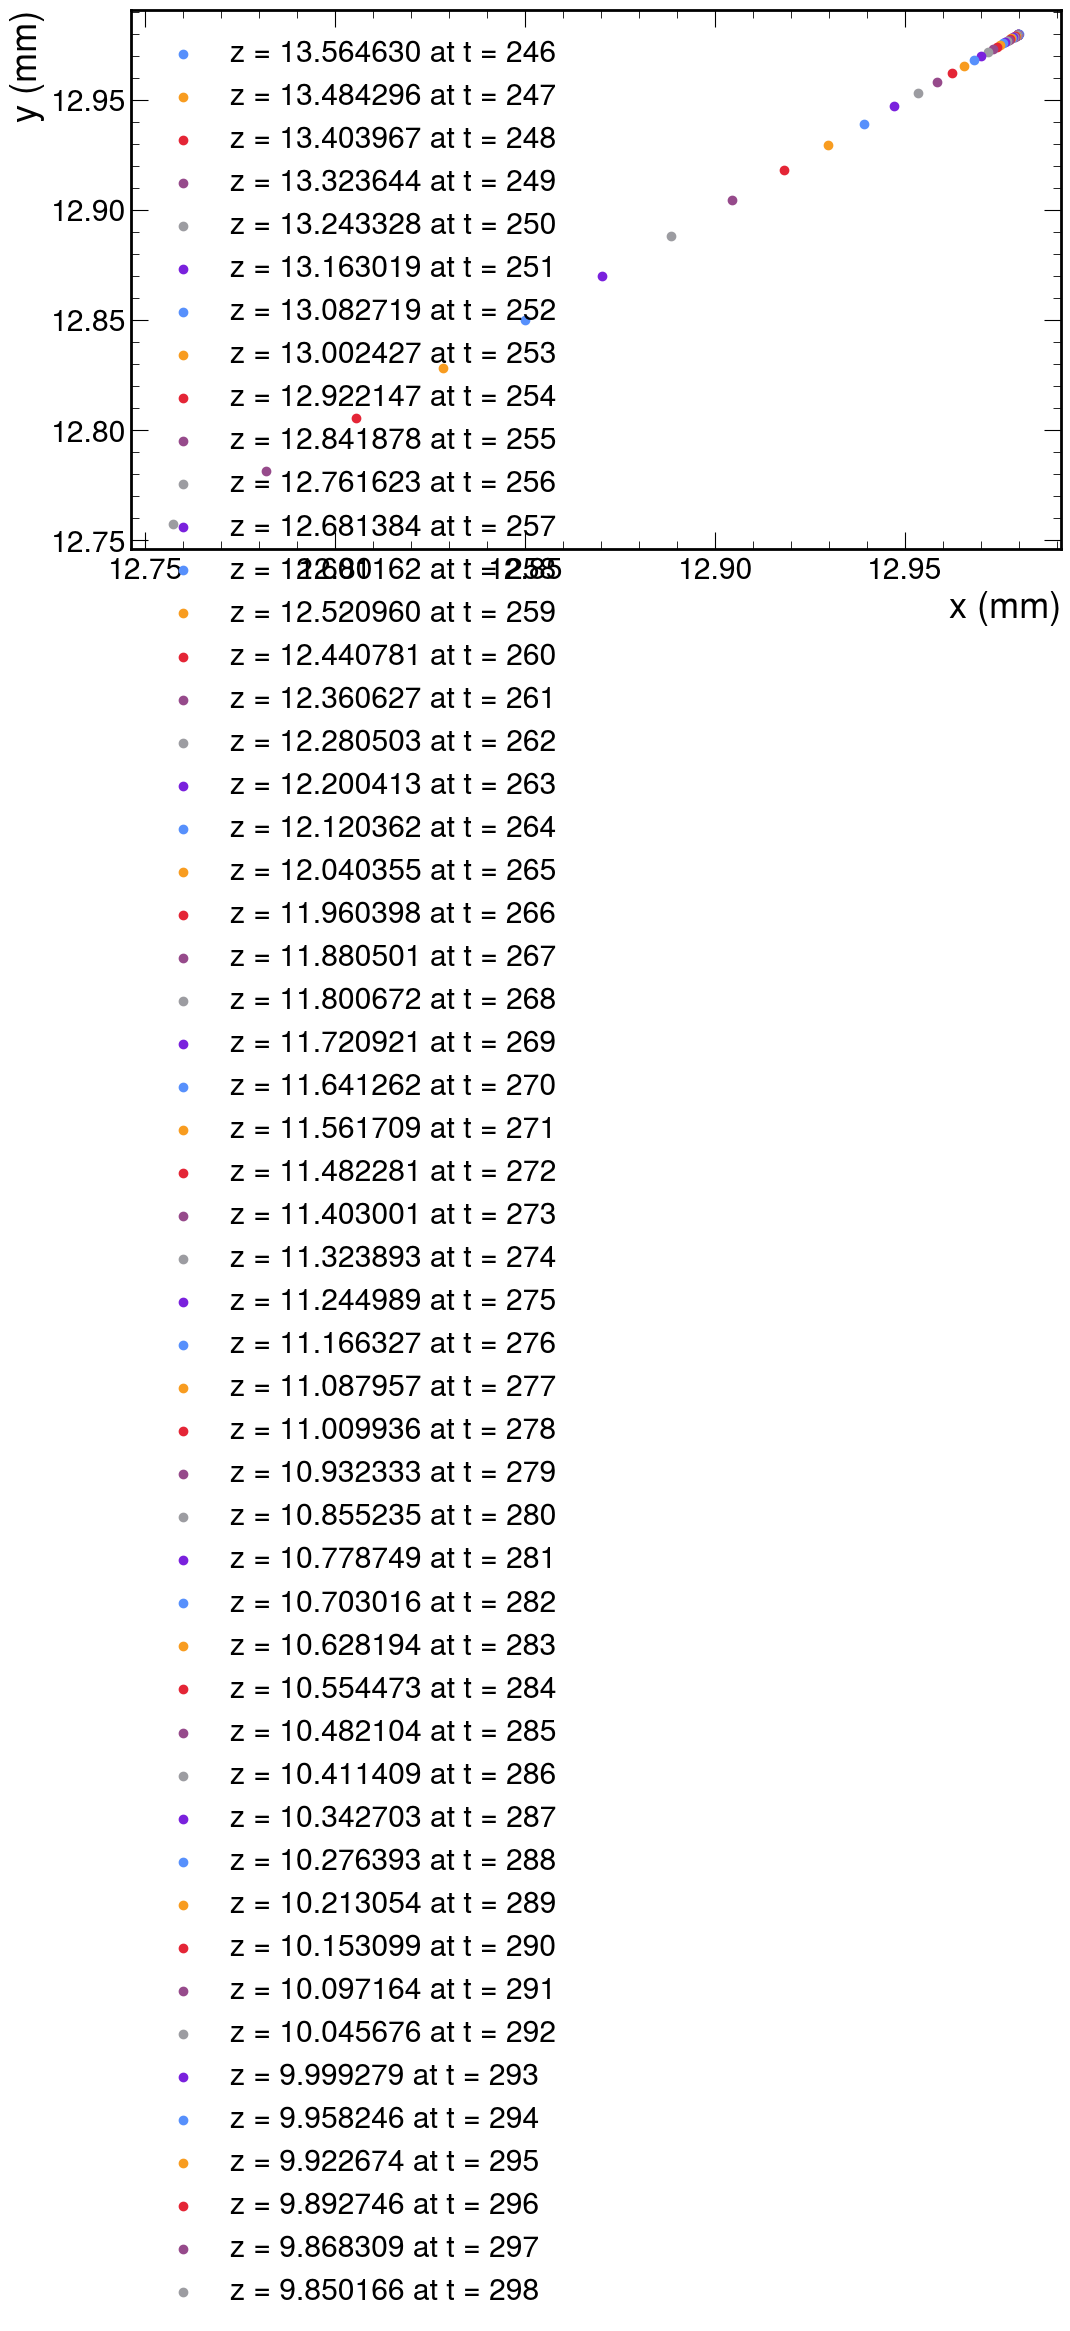

In [643]:
t = 246
plt.figure(figsize=(12,7))
for i in range(data.shape[0]):
    plt.scatter(data[i][0], data[i][1], label=f'z = {data[i][2]:.6f} at t = {t+i}')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')

plt.legend()

In [644]:
os.listdir('/'.join([path_to_data, 'initial']))

['drift3d.json', 'weight3d.json', 'weight3d.npz', 'drift3d.npz']

In [645]:
drift_domain = np.load('/'.join([path_to_data, 'boundary/drift3d.npz']))['drift3d']

In [646]:
drift_domain.shape

(44, 44, 300)

In [647]:
drift_domain[:,:, 101]

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(44, 44))

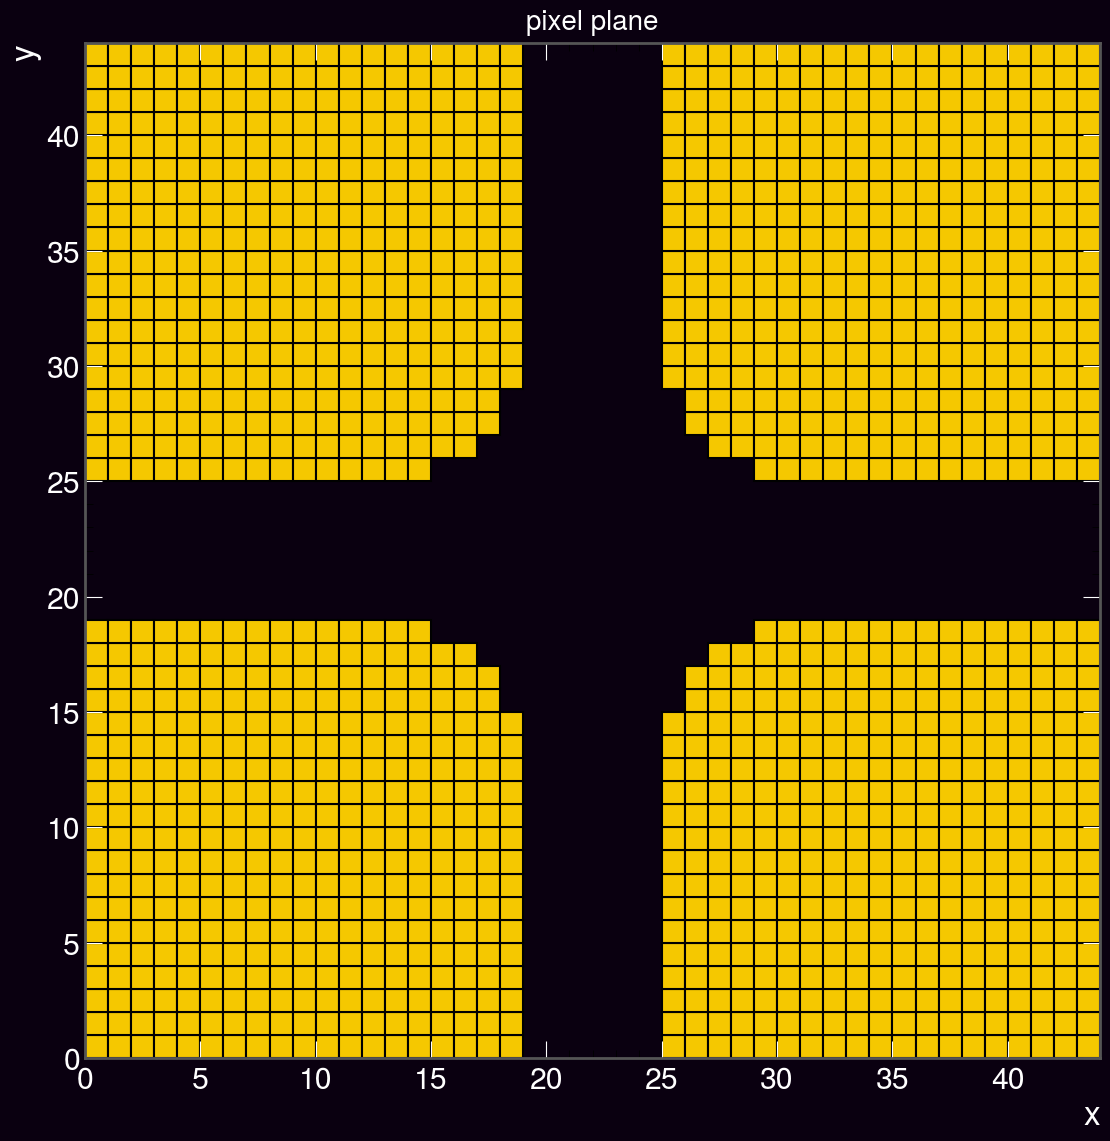

In [648]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

arr = np.ones((44, 44, 1), dtype=int)
arr[:, 19:25, :] = 0
arr[19:25, :, :] = 0

def trimCorner(arr, x, y, z1, z2, corner):
    if corner==0:
        arr[x-3:x+1, y, z1:z2]=0
        arr[x, y-3:y+1, z1:z2]=0
        arr[x, y, z1:z2]=0
        arr[x-1, y-1, z1:z2]=0
    if corner==1:
        arr[x-3:x+1, y, z1:z2]=0
        arr[x, y:y+4, z1:z2]=0
        arr[x, y, z1:z2]=0
        arr[x-1, y+1, z1:z2]=0
    if corner==2:
        arr[x:x+4, y, z1:z2]=0
        arr[x, y:y+4, z1:z2]=0
        arr[x, y, z1:z2]=0
        arr[x+1, y+1, z1:z2]=0
    if corner==3:
        arr[x:x+4, y, z1:z2]=0
        arr[x, y-3:y+1, z1:z2]=0
        arr[x, y, z1:z2]=0
        arr[x+1, y-1, z1:z2]=0

z1, z2 = 0, 1
trimCorner(arr, 18, 18, z1, z2, 0)
trimCorner(arr, 25, 18, z1, z2, 3)
trimCorner(arr, 18, 25, z1, z2, 1)
trimCorner(arr, 25, 25, z1, z2, 2)

data = arr[:, :, 0]

fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('#0a0010')
ax.set_facecolor('#0a0010')

for row in range(44):
    for col in range(44):
        if data[row, col] == 1:
            # Filled: bright yellow square with strong dark border
            rect = Rectangle((col, row), 1, 1,
                              linewidth=1.5,
                              edgecolor='#000000',
                              facecolor='#f5c800')
            ax.add_patch(rect)
#         # else:
#         #     # Empty: just a subtle outline so grid structure is still visible
#         #     rect = Rectangle((col, row), 1, 1,
#         #                       linewidth=0.5,
#         #                       edgecolor='#2a0035',
#         #                       facecolor='#0a0010')
#         #     ax.add_patch(rect)
# ax.imshow(data, origin='lower', extent=[0,100,0,44])

ax.set_xlim(0, 44)
ax.set_ylim(0, 44)
ax.set_aspect('equal')
ax.set_title('pixel plane', color='white', fontsize=20, pad=10)
ax.set_xlabel('x', color='white', fontsize=24)
ax.set_ylabel('y', color='white', fontsize=24)
ax.tick_params(colors='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#555')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/chamfer_grid2.png', dpi=180,
#             bbox_inches='tight', facecolor=fig.get_facecolor())
# print("Done")
plt.show()

In [649]:
weight3d = np.load('/'.join([path_to_data, 'potential/weight3d.npz']))['weight3d']
weight3d.shape

(220, 220, 300)

Text(0.5, 1.0, 'Weighting potential at\n x = 110 tick = 11 mm')

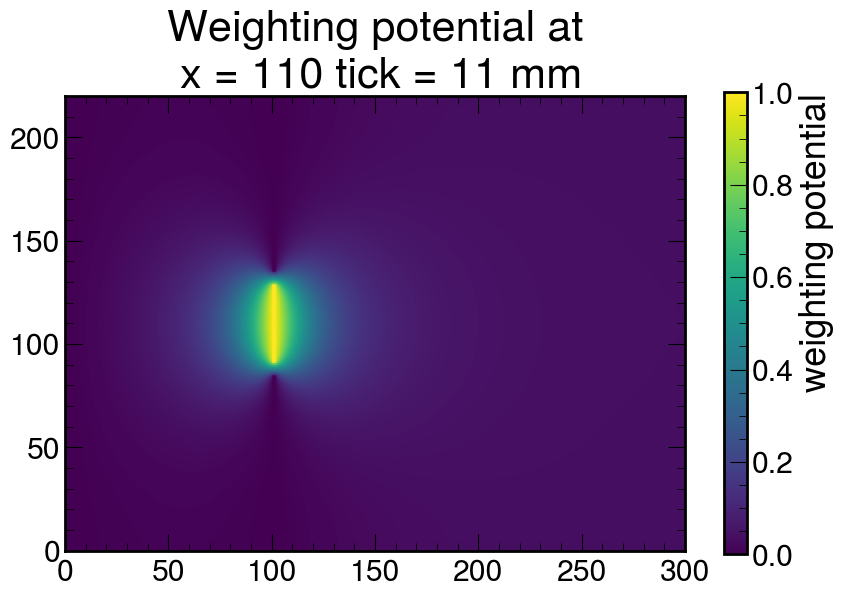

In [652]:
plt.figure(figsize=(10, 6))
plt.imshow(weight3d[110, :, :], origin='lower', extent=[0, 300, 0, 220])
plt.colorbar(label='weighting potential')
plt.title('Weighting potential at\n x = 110 tick = 11 mm')

In [ ]:
11/0.05, 1.9/0.05

(220.0, 37.99999999999999)

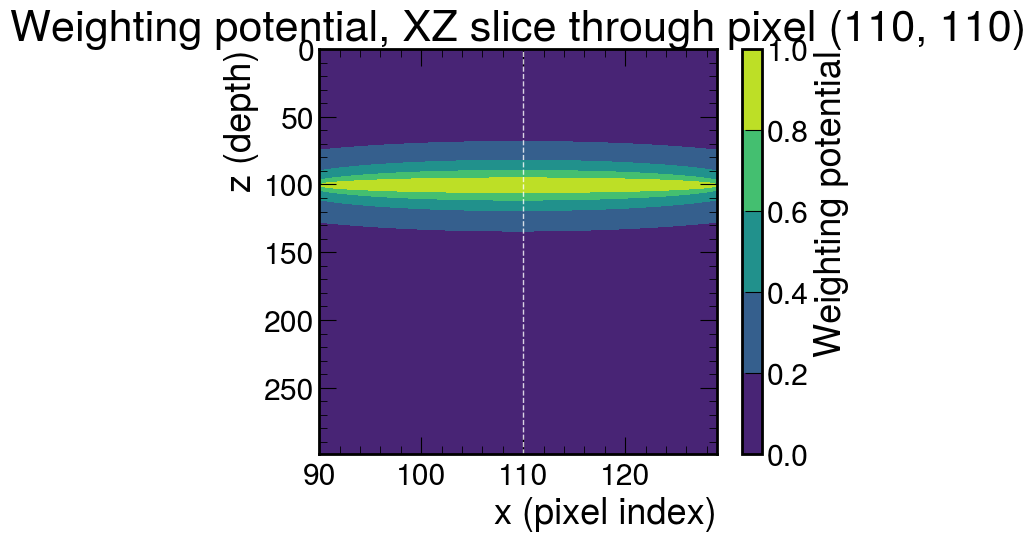

In [656]:
"""
Plot a vertical contour slice (x-z or y-z) through the weighting potential
array, centered on a pixel of interest.

Assumes:
    wp.shape == (Nx, Ny, Nz)   # e.g. (220, 220, 300)
    axis 0 -> x, axis 1 -> y, axis 2 -> z (depth)

Replace the data loading and the parameters below as needed.
"""

import numpy as np
import matplotlib.pyplot as plt


# -------------------- USER PARAMETERS --------------------

# Load your weighting potential array here. Example placeholder:
# wp = np.load("weighting_potential.npy")
# wp = np.random.rand(220, 220, 300)  # <-- replace with your real data
wp = weight3d
# Pixel of interest (in array index coordinates, x and y)
pixel_x = 110
pixel_y = 110

# Which vertical plane to slice through the pixel:
#   "xz" -> slice at fixed y = pixel_y, plot x vs z
#   "yz" -> slice at fixed x = pixel_x, plot y vs z
slice_plane = "xz"

# How many pixels around the pixel of interest to show (half-width, in-plane)
half_width = 20

# Optional physical spacing per array step (set to 1.0 if you just want
# index units). E.g. if each x/y/z step is 10 microns, set dx=dy=dz=10.
dx, dy, dz = 1.0, 1.0, 1.0

# Number of contour levels
n_levels = 5

# -----------------------------------------------------------


def get_slice(wp, pixel_x, pixel_y, plane, half_width):
    Nx, Ny, Nz = wp.shape

    if plane == "xz":
        x0 = max(pixel_x - half_width, 0)
        x1 = min(pixel_x + half_width, Nx)
        data = wp[x0:x1, pixel_y, :]          # shape (x_range, Nz)
        coord = np.arange(x0, x1)
        label = "x (pixel index)"
        center = pixel_x
    elif plane == "yz":
        y0 = max(pixel_y - half_width, 0)
        y1 = min(pixel_y + half_width, Ny)
        data = wp[pixel_x, y0:y1, :]          # shape (y_range, Nz)
        coord = np.arange(y0, y1)
        label = "y (pixel index)"
        center = pixel_y
    else:
        raise ValueError("slice_plane must be 'xz' or 'yz'")

    return data, coord, label, center


data, coord, in_plane_label, center = get_slice(
    wp, pixel_x, pixel_y, slice_plane, half_width
)

z_coord = np.arange(wp.shape[2])

# data has shape (n_in_plane, Nz); transpose so z is on the vertical axis
Z, C = np.meshgrid(z_coord * dz, coord * (dx if slice_plane == "xz" else dy))

fig, ax = plt.subplots(figsize=(7, 6))

cf = ax.contourf(C, Z, data, levels=n_levels, cmap="viridis")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Weighting potential")

# Mark the pixel of interest location (in-plane center, z=0 assumed as surface)
ax.axvline(center * (dx if slice_plane == "xz" else dy),
           color="white", linestyle="--", linewidth=1, alpha=0.8)

ax.set_xlabel(in_plane_label)
ax.set_ylabel("z (depth)")
ax.set_title(f"Weighting potential, {slice_plane.upper()} slice through pixel "
             f"({pixel_x}, {pixel_y})")

ax.invert_yaxis()  # often depth increases downward into the detector; remove if not desired

plt.tight_layout()
# plt.savefig("weighting_potential_slice.png", dpi=200)
plt.show()